In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
#Input defines the number of input features.
#Dense creates a fully connected layer.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
#Dataset
# Each row contains:
# [study_hours, attendance_percentage]

X = np.array([
    [1, 35],
    [2, 40],
    [2, 50],
    [3, 45],
    [3, 60],
    [4, 55],
    [4, 65],
    [5, 60],
    [5, 70],
    [6, 65],
    [6, 75],
    [7, 70],
    [7, 80],
    [8, 75],
    [8, 85],
    [9, 80],
    [9, 90],
    [10, 95],
    [4, 40],
    [7, 90]
], dtype=np.float32)

# 0 = Fail
# 1 = Pass

y = np.array([
    0,
    0,
    0,
    0,
    0,
    0,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    0,
    1
], dtype=np.float32)

In [3]:
print("Input data:")
print(X)

print("\nOutput labels:")
print(y)

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Input data:
[[ 1. 35.]
 [ 2. 40.]
 [ 2. 50.]
 [ 3. 45.]
 [ 3. 60.]
 [ 4. 55.]
 [ 4. 65.]
 [ 5. 60.]
 [ 5. 70.]
 [ 6. 65.]
 [ 6. 75.]
 [ 7. 70.]
 [ 7. 80.]
 [ 8. 75.]
 [ 8. 85.]
 [ 9. 80.]
 [ 9. 90.]
 [10. 95.]
 [ 4. 40.]
 [ 7. 90.]]

Output labels:
[0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.]

Shape of X: (20, 2)
Shape of y: (20,)


This means:

20 student records
2 input features
1 target per student

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    
)

In [5]:
#scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
#Build the neural network
model = Sequential([
    Input(shape=(2,)),

    Dense(
        units=4,
        activation="relu",
        name="hidden_layer"
    ),

    Dense(
        units=1,
        activation="sigmoid",
        name="output_layer"
    )
])

Hidden layer:
Dense(units=4, activation="relu")

This creates four hidden neurons.

Each hidden neuron performs:

z=x1.w1+x2.w2+bias

Then applies ReLU:

a=max(0,z)

Each of the four neurons has:

Two incoming weights
One bias

Therefore, the hidden layer has:

Weights = 2 inputs × 4 neurons = 8
Biases  = 4 neurons            = 4
Total parameters               = 12

Output Layer
Dense(units=1, activation="sigmoid")

This creates one output neuron.

It receives four values from the four hidden neurons.

Therefore:

Weights = 4 hidden outputs × 1 output neuron = 4
Biases  = 1 output neuron                    = 1
Total parameters                             = 5

The sigmoid function converts the final value into a number between 0 and 1:

0.10 → 10% probability of passing
0.70 → 70% probability of passing
0.95 → 95% probability of passing

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#The word None means Keras can accept any number of records in a batch.

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [9]:
#train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=3,
    batch_size=4,
    validation_split=0.20,
    verbose=1
)

Epoch 1/3
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.4167 - loss: 1.0578 - val_accuracy: 0.0000e+00 - val_loss: 1.0643
Epoch 2/3
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4167 - loss: 0.9772 - val_accuracy: 0.0000e+00 - val_loss: 1.0148
Epoch 3/3
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4167 - loss: 0.9073 - val_accuracy: 0.0000e+00 - val_loss: 0.9694


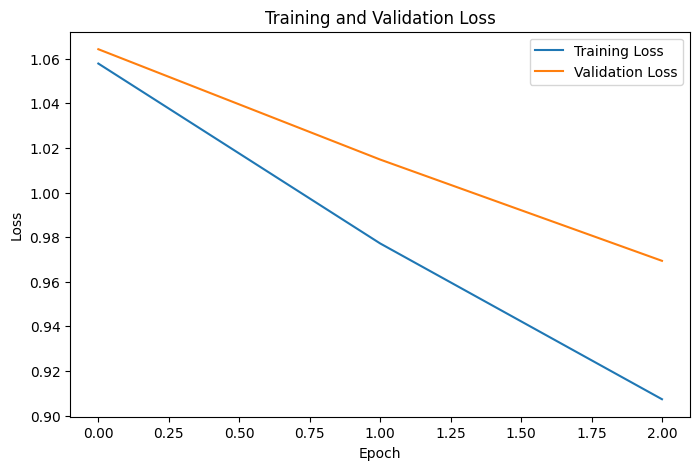

In [10]:
#plot training performance
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

A decreasing training loss indicates that the network is adjusting its weights and biases to make better predictions.

In [12]:
#Evaluate model
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 1.1100044250488281
Test accuracy: 0.5


The testing data was not used to update weights.

Therefore, this checks whether the network can make predictions on unseen records.



In [13]:
#Make prediction
probabilities = model.predict(X_test_scaled, verbose=0)

predicted_classes = (probabilities >= 0.5).astype(int)

print("Probabilities:")
print(probabilities.flatten())

print("\nPredicted classes:")
print(predicted_classes.flatten())

print("\nActual classes:")
print(y_test.astype(int))

Probabilities:
[0.2961535  0.12223607 0.20571475 0.33352777]

Predicted classes:
[0 0 0 0]

Actual classes:
[0 1 1 0]


In [14]:
#predict for new student
new_student = np.array([
    [6, 78]
], dtype=np.float32)

new_student_scaled = scaler.transform(new_student)

pass_probability = model.predict(
    new_student_scaled,
    verbose=0
)[0][0]

predicted_class = int(pass_probability >= 0.5)

print("Pass probability:", pass_probability)

if predicted_class == 1:
    print("Prediction: Student will PASS")
else:
    print("Prediction: Student will FAIL")

Pass probability: 0.38948074
Prediction: Student will FAIL
